In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


df_full = pd.read_csv('data_appl_cleaned.csv')

In [2]:
# Moneyness = 1.0 -> ATM, >1.0 -> ITM, <1.0 -> OTM
df_full['Moneyness'] = df_full['UNDERLYING_LAST'] / df_full['STRIKE']
df_full['T_years'] = df_full['DTE'] / 365.0

df_full['diff_pct'] = abs(df_full['UNDERLYING_LAST'] - df_full['STRIKE']) / df_full['UNDERLYING_LAST']

required_cols = ['vol_garch', 'UNDERLYING_LAST', 'C_LAST', 'Moneyness']
df_full = df_full.dropna(subset=required_cols)

print(f"Тренуємо модель на повному датасеті data_appl_cleaned. Всього записів: {len(df_full)}")

Тренуємо модель на повному датасеті data_appl_cleaned. Всього записів: 772929


In [3]:
# Вчимо модель на всьому: Ціна, Час, Волатильність, Грошовість (Moneyness)
feature_cols = ['UNDERLYING_LAST', 'T_years', 'vol_garch', 'Moneyness']
target_col = ['C_LAST']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_full[feature_cols])
y_scaled = scaler_y.fit_transform(df_full[target_col])

# Спліт 60/20/20 (без перемішування)
n = len(df_full)
train_idx = int(n * 0.6)
val_idx = int(n * 0.8)

X_train = X_scaled[:train_idx]
y_train = y_scaled[:train_idx]
X_val = X_scaled[train_idx:val_idx]
y_val = y_scaled[train_idx:val_idx]
X_test = X_scaled[val_idx:]
y_test = y_scaled[val_idx:]

X_train_lstm = X_train.reshape((X_train.shape[0], 1, len(feature_cols)))
X_val_lstm = X_val.reshape((X_val.shape[0], 1, len(feature_cols)))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, len(feature_cols)))

Починаємо тренування...
Epoch 1/100
7221/7247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0264 
Epoch 1: val_loss improved from None to 0.00055, saving model to best_atm_model.keras
7247/7247 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0010 - mae: 0.0170 - val_loss: 5.5443e-04 - val_mae: 0.0147
Epoch 2/100
7225/7247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.4292e-04 - mae: 0.0136 
Epoch 2: val_loss improved from 0.00055 to 0.00052, saving model to best_atm_model.keras
7247/7247 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 5.3713e-04 - mae: 0.0134 - val_loss: 5.2234e-04 - val_mae: 0.0125
Epoch 3/100
7233/7247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1600e-04 - mae: 0.0130 
Epoch 3: val_loss improved from 0.00052 to 0.00049, saving model to best_atm_model.keras
7247/7247 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 5.1549e-04 - mae: 0.0129 - val_loss: 4.8585e-04 - val_mae: 0.0125
Epoch 4/100
7233/7247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0212e-04 - mae: 0.0127 
Epoch 4: v

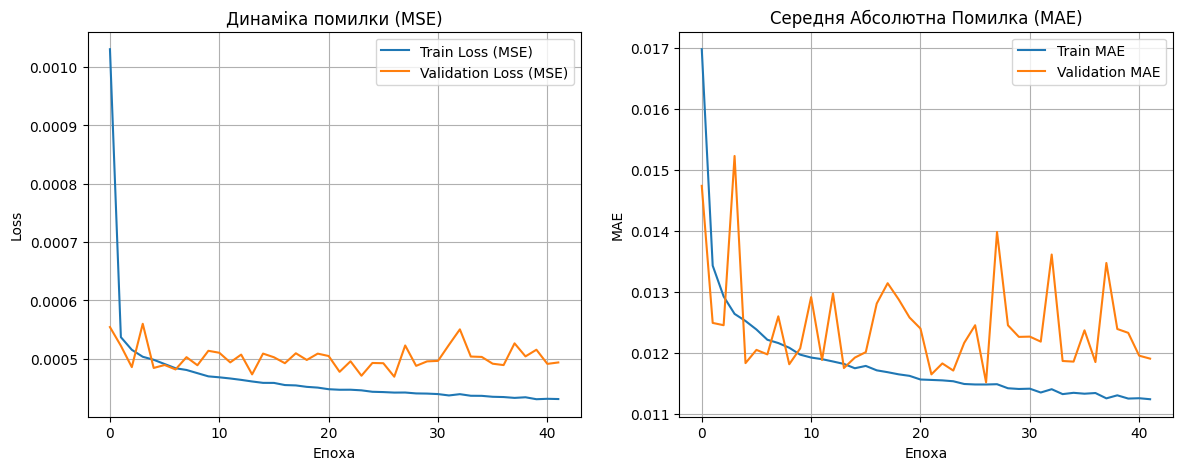

Найкращу модель збережено у файл 'best_atm_model.keras'


In [4]:
model = Sequential()
model.add(Input(shape=(1, len(feature_cols))))
model.add(LSTM(128, activation='tanh', return_sequences=False)) 
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1)) 

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    filepath='best_atm_model.keras',  
    monitor='val_loss',               
    save_best_only=True,              
    mode='min',                       
    verbose=1                         
)

logger = CSVLogger('training_log.csv', append=True)

print("Починаємо тренування...")
history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint, logger], 
    validation_data=(X_val_lstm, y_val),
    verbose=1
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Динаміка помилки (MSE)')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Середня Абсолютна Помилка (MAE)')
plt.xlabel('Епоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()

print("Найкращу модель збережено у файл 'best_atm_model.keras'")

Аналізуємо Страйк 125.0 за 2021 рік...
✅ Знайдено найкращу дату для аналізу: 2021-09-23
Кількість точок (термінів експірації): 20
Ціна активу в цей день: 146.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


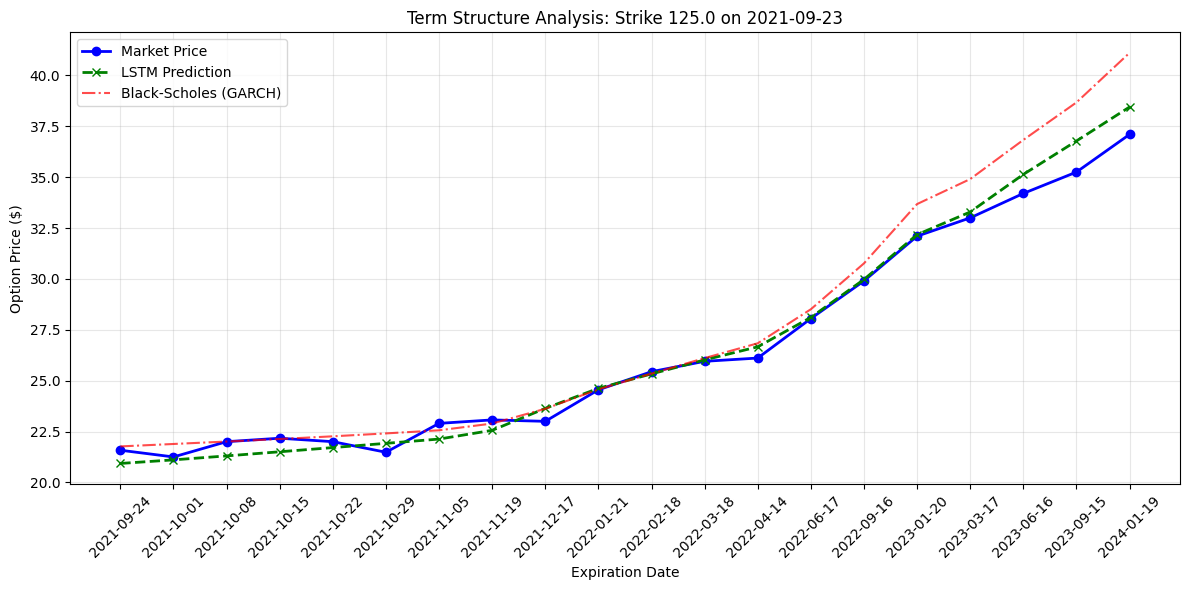

In [5]:
TARGET_STRIKE = 125.0
TARGET_YEAR = 2021

print(f"Аналізуємо Страйк {TARGET_STRIKE} за {TARGET_YEAR} рік...")
best_model = load_model('best_atm_model.keras')

df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['STRIKE'] == TARGET_STRIKE) & (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR)
df_subset = df_analyze[mask].copy()

if len(df_subset) == 0:
    print("❌ Даних для цього страйку в цьому році не знайдено.")
else:
    best_date = df_subset.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data = df_subset[df_subset['QUOTE_DATE'] == best_date].sort_values(col_expire)

    print(f"✅ Знайдено найкращу дату для аналізу: {best_date.date()}")
    print(f"Кількість точок (термінів експірації): {len(plot_data)}")
    print(f"Ціна активу в цей день: {plot_data['UNDERLYING_LAST'].iloc[0]}")

    X_plot = scaler_X.transform(plot_data[feature_cols])
    X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

    RISK_FREE_RATE = 0.05
    def bs_calc(row):
        S = row['UNDERLYING_LAST']; K = row['STRIKE']
        T = row['T_years']; sigma = row['vol_garch']
        if T<=0 or sigma<=0: return max(S-K, 0)
        d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

    bs_preds = plot_data.apply(bs_calc, axis=1)

    plt.figure(figsize=(12, 6))

    x_dates = plot_data[col_expire].dt.strftime('%Y-%m-%d')

    plt.plot(x_dates, plot_data['C_LAST'], label='Market Price', marker='o', color='blue', linewidth=2)
    plt.plot(x_dates, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green', linewidth=2)
    plt.plot(x_dates, bs_preds, label='Black-Scholes (GARCH)', linestyle='-.', color='red', alpha=0.7)

    plt.title(f'Term Structure Analysis: Strike {TARGET_STRIKE} on {best_date.date()}')
    plt.xlabel('Expiration Date')
    plt.ylabel('Option Price ($)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Шукаємо ідеальний ATM сценарій у 2021 році...
✅ Дата з найкращим покриттям ATM: 2021-02-25
💰 Ціна активу в цей день: 121.0
🎯 ATM Страйк: 120.0
📊 Кількість точок на графіку: 18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


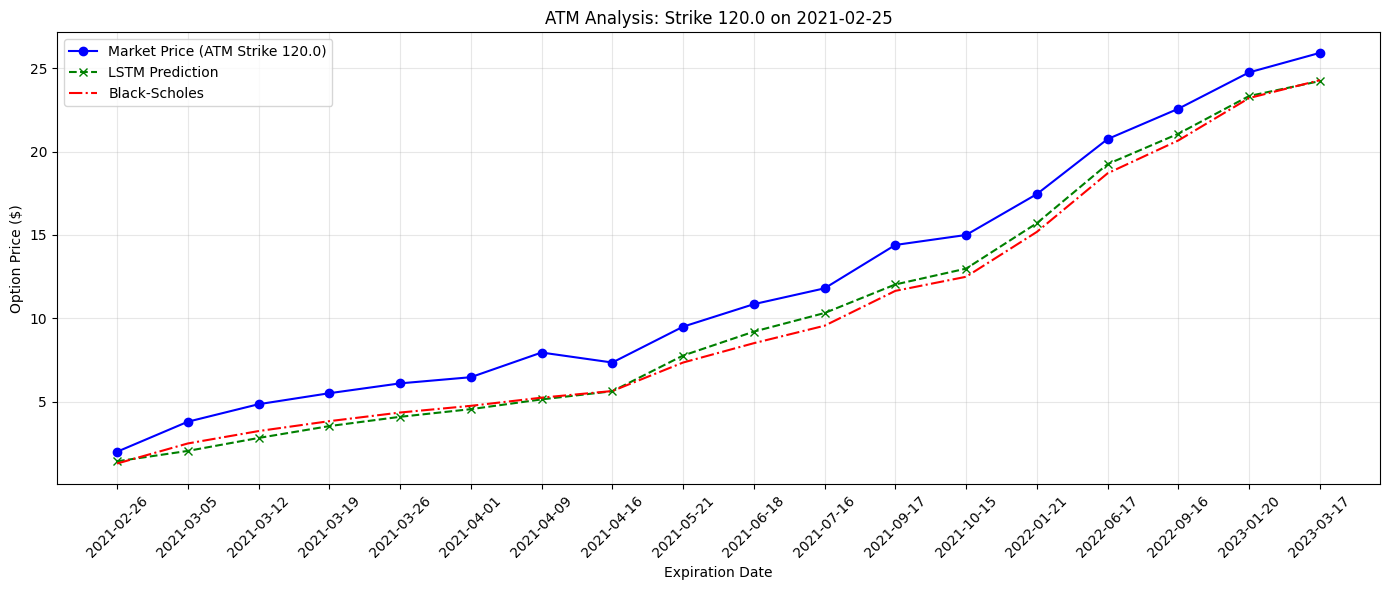

In [6]:
TARGET_YEAR = 2021
print(f"Шукаємо ідеальний ATM сценарій у {TARGET_YEAR} році...")

best_model = load_model('best_atm_model.keras')
df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm_2021 = df_analyze[mask].copy()

if len(df_atm_2021) == 0:
    print("❌ У 2021 році не знайдено опціонів з точністю ATM 1%. Спробуйте збільшити до 2%.")
else:
    best_date = df_atm_2021.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data = df_atm_2021[df_atm_2021['QUOTE_DATE'] == best_date].sort_values(col_expire)
    
    atm_strike_on_that_day = plot_data['STRIKE'].mode()[0]
    
    plot_data = plot_data[plot_data['STRIKE'] == atm_strike_on_that_day]

    print(f"✅ Дата з найкращим покриттям ATM: {best_date.date()}")
    print(f"💰 Ціна активу в цей день: {plot_data['UNDERLYING_LAST'].iloc[0]}")
    print(f"🎯 ATM Страйк: {atm_strike_on_that_day}")
    print(f"📊 Кількість точок на графіку: {len(plot_data)}")

    X_plot = scaler_X.transform(plot_data[feature_cols])
    X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

    RISK_FREE_RATE = 0.05
    def bs_calc(row):
        S = row['UNDERLYING_LAST']; K = row['STRIKE']
        T = row['T_years']; sigma = row['vol_garch']
        if T<=0 or sigma<=0: return max(S-K, 0)
        d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

    bs_preds = plot_data.apply(bs_calc, axis=1)

    plt.figure(figsize=(14, 6))
    x_dates = plot_data[col_expire].dt.strftime('%Y-%m-%d')

    plt.plot(x_dates, plot_data['C_LAST'], label=f'Market Price (ATM Strike {atm_strike_on_that_day})', marker='o', color='blue')
    plt.plot(x_dates, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green')
    plt.plot(x_dates, bs_preds, label='Black-Scholes', linestyle='-.', color='red')

    plt.title(f'ATM Analysis: Strike {atm_strike_on_that_day} on {best_date.date()}')
    plt.xlabel('Expiration Date')
    plt.ylabel('Option Price ($)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Шукаємо ідеальний ATM сценарій у 2021 році...
✅ Дата: 2021-02-25
💰 Ціна: 121.0
🎯 Страйк: 120.0
📊 Кількість точок: 18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


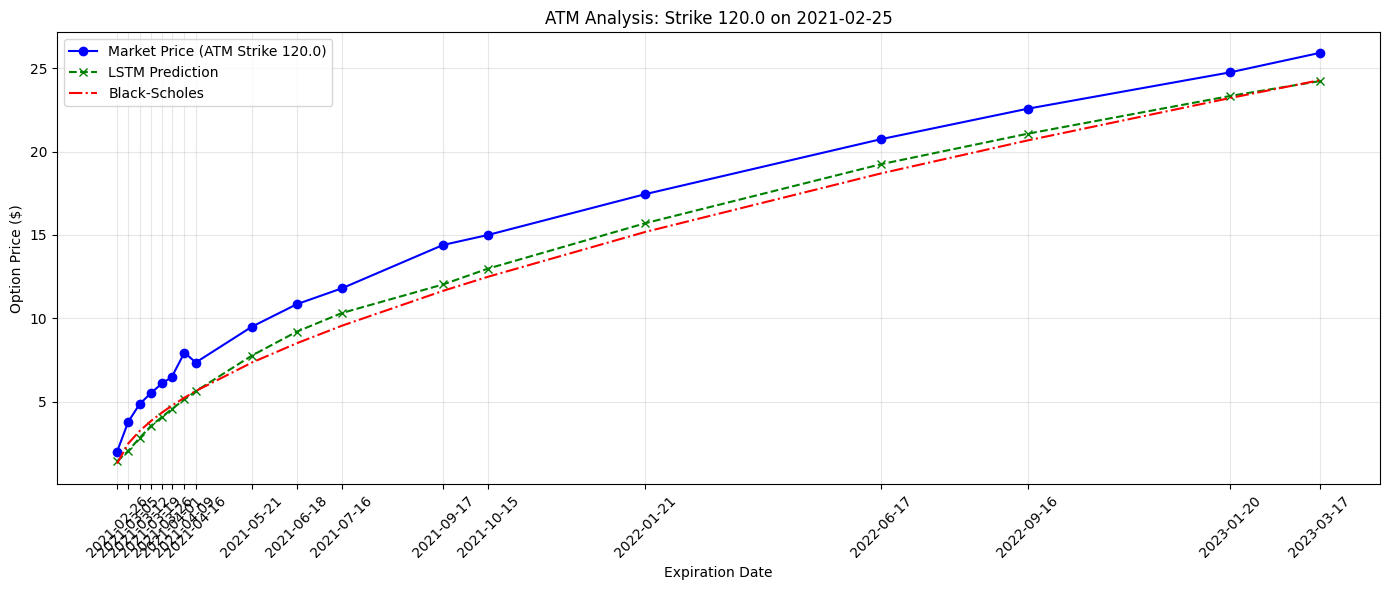

In [7]:
import matplotlib.dates as mdates 

TARGET_YEAR = 2021
print(f"Шукаємо ідеальний ATM сценарій у {TARGET_YEAR} році...")

df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm_2021 = df_analyze[mask].copy()

if len(df_atm_2021) == 0:
    print("❌ У 2021 році не знайдено опціонів з точністю ATM 1%.")
else:
    best_date = df_atm_2021.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data = df_atm_2021[df_atm_2021['QUOTE_DATE'] == best_date].sort_values(col_expire)
    
    atm_strike_on_that_day = plot_data['STRIKE'].mode()[0]
    plot_data = plot_data[plot_data['STRIKE'] == atm_strike_on_that_day]

    print(f"✅ Дата: {best_date.date()}")
    print(f"💰 Ціна: {plot_data['UNDERLYING_LAST'].iloc[0]}")
    print(f"🎯 Страйк: {atm_strike_on_that_day}")
    print(f"📊 Кількість точок: {len(plot_data)}")

    X_plot = scaler_X.transform(plot_data[feature_cols])
    X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

    RISK_FREE_RATE = 0.05
    def bs_calc(row):
        S = row['UNDERLYING_LAST']; K = row['STRIKE']
        T = row['T_years']; sigma = row['vol_garch']
        if T<=0 or sigma<=0: return max(S-K, 0)
        d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

    bs_preds = plot_data.apply(bs_calc, axis=1)

    plt.figure(figsize=(14, 6))

    dates_for_plot = plot_data[col_expire]

    plt.plot(dates_for_plot, plot_data['C_LAST'], label=f'Market Price (ATM Strike {atm_strike_on_that_day})', marker='o', color='blue')
    plt.plot(dates_for_plot, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green')
    plt.plot(dates_for_plot, bs_preds, label='Black-Scholes', linestyle='-.', color='red')

    plt.title(f'ATM Analysis: Strike {atm_strike_on_that_day} on {best_date.date()}')
    plt.xlabel('Expiration Date')
    plt.ylabel('Option Price ($)')
    
    plt.xticks(dates_for_plot, rotation=45)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Шукаємо ATM сценарій у 2021 році (DTE <= 700)...
✅ Дата: 2021-02-25
🎯 Страйк: 120.0
📊 Точок на графіку: 17 (DTE до 700)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


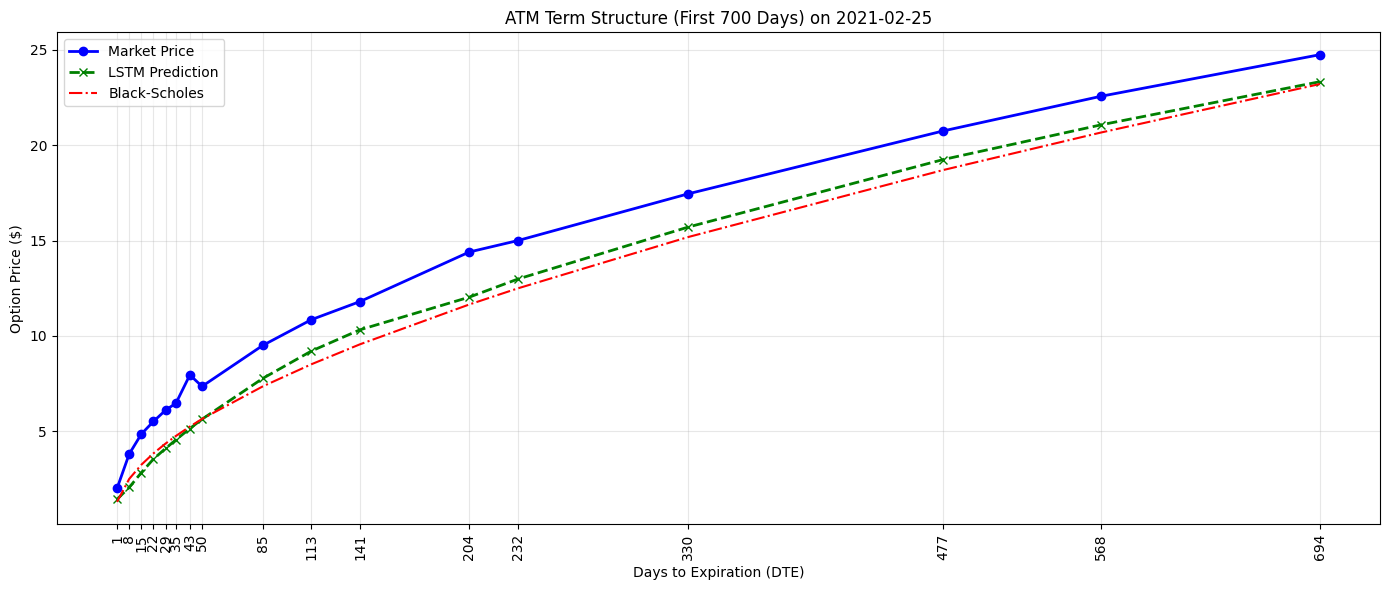

In [8]:
TARGET_YEAR = 2021
MAX_DTE = 700  

print(f"Шукаємо ATM сценарій у {TARGET_YEAR} році (DTE <= {MAX_DTE})...")

df_analyze = df_full.copy()
df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm_2021 = df_analyze[mask].copy()

if len(df_atm_2021) == 0:
    print("❌ Даних не знайдено.")
else:
    best_date = df_atm_2021.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data_full = df_atm_2021[df_atm_2021['QUOTE_DATE'] == best_date].sort_values('DTE')
    
    atm_strike = plot_data_full['STRIKE'].mode()[0]
    
    plot_data = plot_data_full[plot_data_full['STRIKE'] == atm_strike]
    
    plot_data = plot_data[plot_data['DTE'] <= MAX_DTE]
    
    if len(plot_data) < 3:
        print(f"⚠️ Замало точок (менше 3) в діапазоні {MAX_DTE} днів. Спробуйте збільшити MAX_DTE.")
    else:
        print(f"✅ Дата: {best_date.date()}")
        print(f"🎯 Страйк: {atm_strike}")
        print(f"📊 Точок на графіку: {len(plot_data)} (DTE до {MAX_DTE})")

        X_plot = scaler_X.transform(plot_data[feature_cols])
        X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

        lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

        RISK_FREE_RATE = 0.05
        def bs_calc(row):
            S = row['UNDERLYING_LAST']; K = row['STRIKE']
            T = row['T_years']; sigma = row['vol_garch']
            if T<=0 or sigma<=0: return max(S-K, 0)
            d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

        bs_preds = plot_data.apply(bs_calc, axis=1)

        plt.figure(figsize=(14, 6)) 
        
        x_values = plot_data['DTE']

        plt.plot(x_values, plot_data['C_LAST'], label='Market Price', marker='o', color='blue', linewidth=2)
        plt.plot(x_values, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green', linewidth=2)
        plt.plot(x_values, bs_preds, label='Black-Scholes', linestyle='-.', color='red')

        plt.title(f'ATM Term Structure (First {MAX_DTE} Days) on {best_date.date()}')
        plt.xlabel('Days to Expiration (DTE)')
        plt.ylabel('Option Price ($)')
        
        plt.xticks(x_values, rotation=90) 
        
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [9]:
TARGET_YEAR = 2021
MAX_DTE = 700 
RISK_FREE_RATE = 0.05

print(f"--- Аналіз похибок (Рік: {TARGET_YEAR}, DTE <= {MAX_DTE}) ---")

df_analyze = df_full.copy()
df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm = df_analyze[mask].copy()

if len(df_atm) == 0:
    print("❌ Даних не знайдено.")
else:
    best_date = df_atm.groupby('QUOTE_DATE')['DTE'].count().idxmax()

    data = df_atm[df_atm['QUOTE_DATE'] == best_date].sort_values('DTE')
    atm_strike = data['STRIKE'].mode()[0]
    data = data[(data['STRIKE'] == atm_strike) & (data['DTE'] <= MAX_DTE)].copy()

    print(f"Дата: {best_date.date()} | Страйк: {atm_strike} | Точок: {len(data)}")

    X_val = scaler_X.transform(data[feature_cols])
    X_val = X_val.reshape((X_val.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_val, verbose=0)).flatten()

    results = pd.DataFrame()
    results['Expiry'] = data[col_expire].dt.date
    results['DTE'] = data['DTE']
    results['Market ($)'] = data['C_LAST']
    results['LSTM ($)'] = lstm_preds

    results['Diff ($)'] = results['LSTM ($)'] - results['Market ($)']

    results['Diff (%)'] = (results['Diff ($)'] / results['Market ($)']) * 100

    results = results.round(2)

    print("\n" + "="*65)
    print(f" ПОРІВНЯЛЬНА ТАБЛИЦЯ (ATM Strike {atm_strike})")
    print("="*65)
    print(results.to_string(index=False))
    
    avg_error_usd = np.mean(np.abs(results['Diff ($)']))
    avg_error_pct = np.mean(np.abs(results['Diff (%)']))
    
    print("-" * 65)
    print(f"Середня помилка в доларах (MAE):  ${avg_error_usd:.2f}")
    print(f"Середня помилка у відсотках (MAPE): {avg_error_pct:.2f}%")
    print("-" * 65)

--- Аналіз похибок (Рік: 2021, DTE <= 700) ---
Дата: 2021-02-25 | Страйк: 120.0 | Точок: 17

 ПОРІВНЯЛЬНА ТАБЛИЦЯ (ATM Strike 120.0)
    Expiry    DTE  Market ($)  LSTM ($)  Diff ($)  Diff (%)
2021-02-26   1.00        2.00      1.43     -0.57    -28.59
2021-03-05   8.00        3.80      2.05     -1.75    -46.07
2021-03-12  15.00        4.85      2.83     -2.02    -41.73
2021-03-19  21.96        5.51      3.54     -1.97    -35.78
2021-03-26  28.96        6.10      4.09     -2.01    -32.88
2021-04-01  34.96        6.47      4.55     -1.92    -29.63
2021-04-09  42.96        7.95      5.14     -2.81    -35.36
2021-04-16  49.96        7.35      5.63     -1.72    -23.43
2021-05-21  84.96        9.50      7.77     -1.73    -18.23
2021-06-18 112.96       10.85      9.20     -1.65    -15.17
2021-07-16 140.96       11.80     10.32     -1.48    -12.55
2021-09-17 203.96       14.40     12.03     -2.37    -16.44
2021-10-15 231.96       15.00     12.98     -2.02    -13.46
2022-01-21 330.00       17.

Шукаємо ATM сценарій у 2023 році (DTE <= 700)...
✅ Дата: 2023-01-26
🎯 Страйк: 145.0
📊 Точок на графіку: 20 (DTE до 700)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


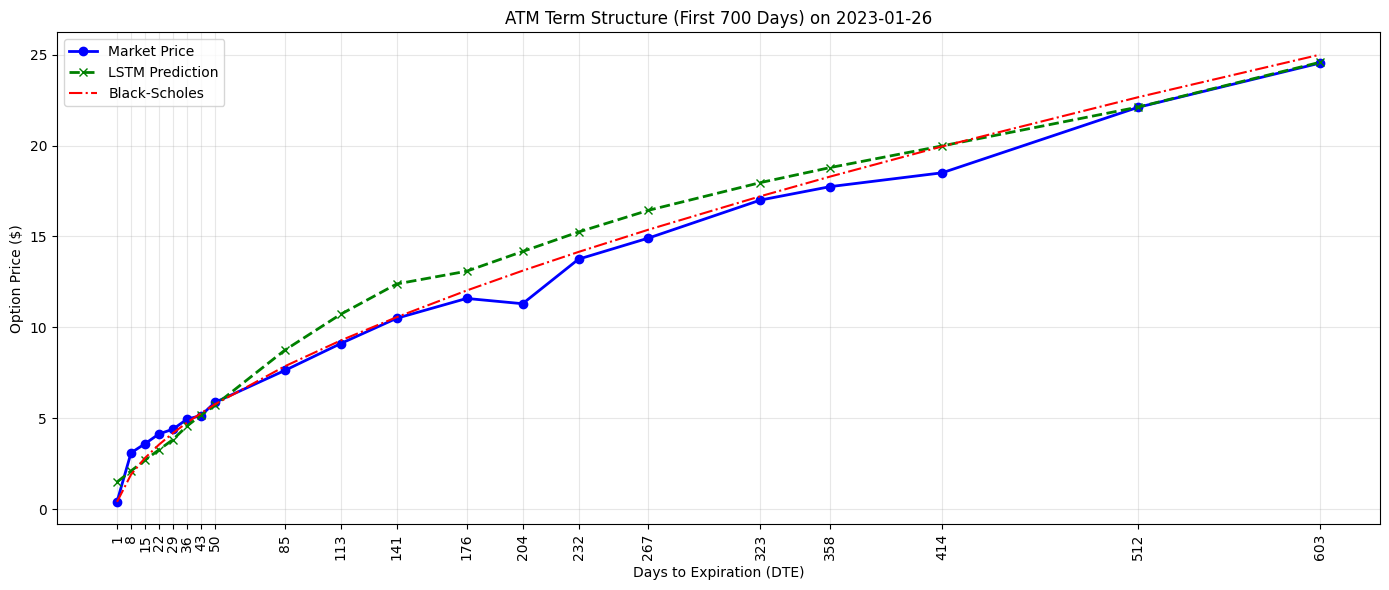

In [10]:
TARGET_YEAR = 2023
MAX_DTE = 700  

print(f"Шукаємо ATM сценарій у {TARGET_YEAR} році (DTE <= {MAX_DTE})...")

df_analyze = df_full.copy()
df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm_2023 = df_analyze[mask].copy()

if len(df_atm_2023) == 0:
    print("❌ Даних не знайдено.")
else:
    best_date = df_atm_2023.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data_full = df_atm_2023[df_atm_2023['QUOTE_DATE'] == best_date].sort_values('DTE')
    
    atm_strike = plot_data_full['STRIKE'].mode()[0]
    
    plot_data = plot_data_full[plot_data_full['STRIKE'] == atm_strike]
    
    plot_data = plot_data[plot_data['DTE'] <= MAX_DTE]
    
    if len(plot_data) < 3:
        print(f"⚠️ Замало точок (менше 3) в діапазоні {MAX_DTE} днів. Спробуйте збільшити MAX_DTE.")
    else:
        print(f"✅ Дата: {best_date.date()}")
        print(f"🎯 Страйк: {atm_strike}")
        print(f"📊 Точок на графіку: {len(plot_data)} (DTE до {MAX_DTE})")

        X_plot = scaler_X.transform(plot_data[feature_cols])
        X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

        lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

        RISK_FREE_RATE = 0.05
        def bs_calc(row):
            S = row['UNDERLYING_LAST']; K = row['STRIKE']
            T = row['T_years']; sigma = row['vol_garch']
            if T<=0 or sigma<=0: return max(S-K, 0)
            d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

        bs_preds = plot_data.apply(bs_calc, axis=1)

        plt.figure(figsize=(14, 6)) 
        
        x_values = plot_data['DTE']

        plt.plot(x_values, plot_data['C_LAST'], label='Market Price', marker='o', color='blue', linewidth=2)
        plt.plot(x_values, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green', linewidth=2)
        plt.plot(x_values, bs_preds, label='Black-Scholes', linestyle='-.', color='red')

        plt.title(f'ATM Term Structure (First {MAX_DTE} Days) on {best_date.date()}')
        plt.xlabel('Days to Expiration (DTE)')
        plt.ylabel('Option Price ($)')
        
        plt.xticks(x_values, rotation=90) 
        
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


Шукаємо ідеальний ATM сценарій у 2023 році...
✅ Дата: 2023-01-26
💰 Ціна: 143.93
🎯 Страйк: 145.0
📊 Кількість точок: 23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


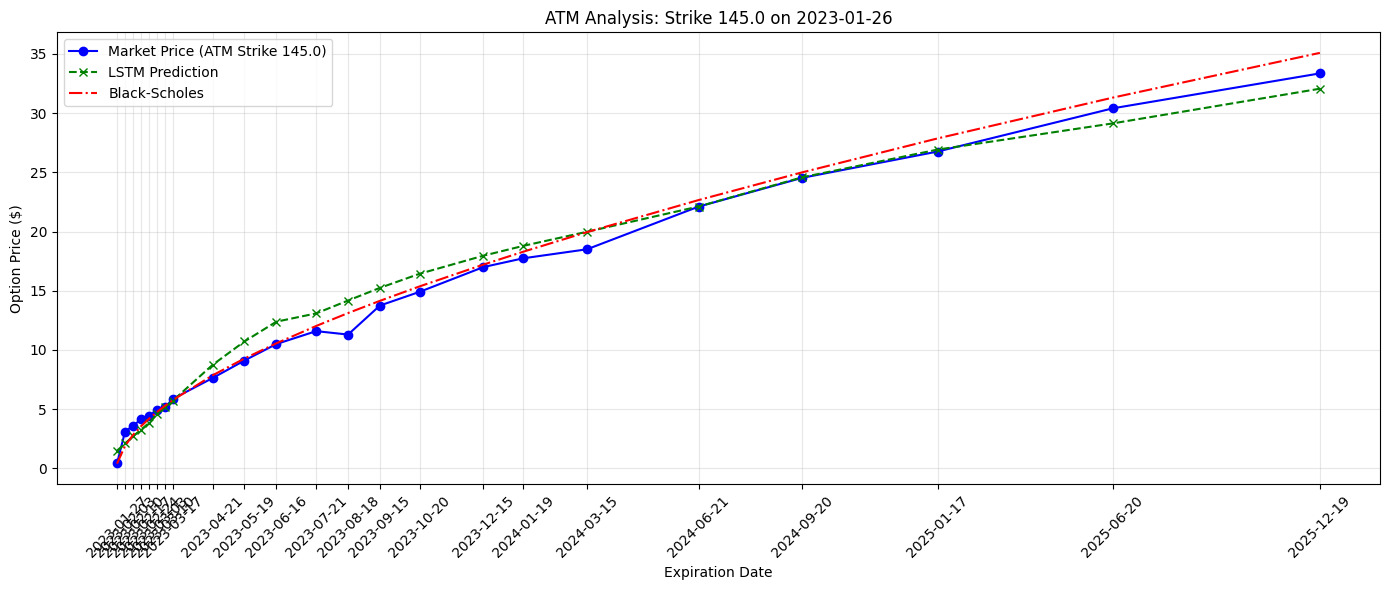

In [11]:
TARGET_YEAR = 2023
print(f"Шукаємо ідеальний ATM сценарій у {TARGET_YEAR} році...")

df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm_2023 = df_analyze[mask].copy()

if len(df_atm_2023) == 0:
    print("❌ У 2023 році не знайдено опціонів з точністю ATM 1%.")
else:
    best_date = df_atm_2023.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data = df_atm_2023[df_atm_2023['QUOTE_DATE'] == best_date].sort_values(col_expire)
    
    atm_strike_on_that_day = plot_data['STRIKE'].mode()[0]
    plot_data = plot_data[plot_data['STRIKE'] == atm_strike_on_that_day]

    print(f"✅ Дата: {best_date.date()}")
    print(f"💰 Ціна: {plot_data['UNDERLYING_LAST'].iloc[0]}")
    print(f"🎯 Страйк: {atm_strike_on_that_day}")
    print(f"📊 Кількість точок: {len(plot_data)}")

    X_plot = scaler_X.transform(plot_data[feature_cols])
    X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

    RISK_FREE_RATE = 0.05
    def bs_calc(row):
        S = row['UNDERLYING_LAST']; K = row['STRIKE']
        T = row['T_years']; sigma = row['vol_garch']
        if T<=0 or sigma<=0: return max(S-K, 0)
        d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

    bs_preds = plot_data.apply(bs_calc, axis=1)

    plt.figure(figsize=(14, 6))

    dates_for_plot = plot_data[col_expire]

    plt.plot(dates_for_plot, plot_data['C_LAST'], label=f'Market Price (ATM Strike {atm_strike_on_that_day})', marker='o', color='blue')
    plt.plot(dates_for_plot, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green')
    plt.plot(dates_for_plot, bs_preds, label='Black-Scholes', linestyle='-.', color='red')

    plt.title(f'ATM Analysis: Strike {atm_strike_on_that_day} on {best_date.date()}')
    plt.xlabel('Expiration Date')
    plt.ylabel('Option Price ($)')
    
    plt.xticks(dates_for_plot, rotation=45)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [21]:
TARGET_YEAR = 2023
MAX_DTE = 700 
RISK_FREE_RATE = 0.05

print(f"--- Аналіз похибок (Рік: {TARGET_YEAR}, DTE <= {MAX_DTE}) ---")

df_analyze = df_full.copy()
df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm = df_analyze[mask].copy()

if len(df_atm) == 0:
    print("❌ Даних не знайдено.")
else:
    best_date = df_atm.groupby('QUOTE_DATE')['DTE'].count().idxmax()

    data = df_atm[df_atm['QUOTE_DATE'] == best_date].sort_values('DTE')
    atm_strike = data['STRIKE'].mode()[0]
    data = data[(data['STRIKE'] == atm_strike) & (data['DTE'] <= MAX_DTE)].copy()

    print(f"Дата: {best_date.date()} | Страйк: {atm_strike} | Точок: {len(data)}")

    X_val = scaler_X.transform(data[feature_cols])
    X_val = X_val.reshape((X_val.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_val, verbose=0)).flatten()

    results = pd.DataFrame()
    results['Expiry'] = data[col_expire].dt.date
    results['DTE'] = data['DTE']
    results['Market ($)'] = data['C_LAST']
    results['LSTM ($)'] = lstm_preds

    results['Diff ($)'] = results['LSTM ($)'] - results['Market ($)']

    results['Diff (%)'] = (results['Diff ($)'] / results['Market ($)']) * 100

    results = results.round(2)

    print("\n" + "="*65)
    print(f" ПОРІВНЯЛЬНА ТАБЛИЦЯ (ATM Strike {atm_strike})")
    print("="*65)
    print(results.to_string(index=False))
    
    avg_error_usd = np.mean(np.abs(results['Diff ($)']))
    avg_error_pct = np.mean(np.abs(results['Diff (%)']))
    
    print("-" * 65)
    print(f"Середня помилка в доларах (MAE):  ${avg_error_usd:.2f}")
    print(f"Середня помилка у відсотках (MAPE): {avg_error_pct:.2f}%")
    print("-" * 65)

--- Аналіз похибок (Рік: 2023, DTE <= 700) ---
Дата: 2020-09-11 | Страйк: 85.0 | Точок: 17

 ПОРІВНЯЛЬНА ТАБЛИЦЯ (ATM Strike 85.0)
    Expiry    DTE  Market ($)  LSTM ($)  Diff ($)  Diff (%)
2020-09-11   0.00       27.00 28.100000      1.10      4.07
2020-09-18   7.00       27.10 28.450001      1.35      4.98
2020-09-25  14.00       26.55 28.750000      2.20      8.29
2020-10-02  21.00       33.30 29.049999     -4.25    -12.77
2020-10-09  28.00       33.05 29.309999     -3.74    -11.30
2020-10-16  35.00       27.55 29.520000      1.97      7.17
2020-10-23  42.00       30.50 29.730000     -0.77     -2.52
2020-10-30  49.00       26.50 29.930000      3.43     12.96
2020-11-20  70.04       28.24 30.520000      2.28      8.06
2020-12-18  98.04       27.74 31.240000      3.50     12.60
2021-01-15 126.04       28.20 31.830000      3.63     12.88
2021-03-19 189.00       30.10 33.099998      3.00      9.95
2021-04-16 217.00       35.87 33.599998     -2.27     -6.32
2021-06-18 280.00       30.65

In [28]:
from scipy.stats import norm

RISK_FREE_RATE = 0.05

def bs_calc(row):
    S = row['UNDERLYING_LAST']
    K = row['STRIKE']
    T = row['T_years']
    sigma = row['vol_garch']

    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return max(S - K, 0)

    d1 = (np.log(S / K) + (RISK_FREE_RATE + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-RISK_FREE_RATE * T) * norm.cdf(d2)


print(f"--- Аналіз похибок (LSTM vs Black–Scholes, УСІ ДАНІ) ---")

df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

data = df_analyze.sort_values(['QUOTE_DATE', 'DTE']).copy()

if len(data) == 0:
    print("❌ Даних не знайдено.")
else:
    print(f"Кількість опціонів: {len(data)}")

    # ---------- LSTM ----------
    X_val = scaler_X.transform(data[feature_cols])
    X_val = X_val.reshape((X_val.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(
        best_model.predict(X_val, verbose=0)
    ).flatten()

    # ---------- Black–Scholes ----------
    bs_prices = data.apply(bs_calc, axis=1)

    # ---------- Таблиця результатів ----------
    results_all = pd.DataFrame()
    results_all['Asset'] = data['UNDERLYING_LAST']
    results_all['Quote Date'] = data['QUOTE_DATE'].dt.date
    results_all['Expiry'] = data[col_expire].dt.date
    results_all['Strike'] = data['STRIKE']
    results_all['DTE'] = data['DTE']

    results_all['Market ($)'] = data['C_LAST']
    results_all['LSTM ($)'] = lstm_preds
    results_all['BS ($)'] = bs_prices

    results = results_all[
    (results_all['DTE'] > 0) &
    (results_all['Market ($)'] > 0.5)
    ].copy()
    
    # ---------- Похибки ----------
    results['Diff LSTM ($)'] = results['LSTM ($)'] - results['Market ($)']
    results['Diff LSTM (%)'] = results['Diff LSTM ($)'] / results['Market ($)'] * 100

    results['Diff BS ($)'] = results['BS ($)'] - results['Market ($)']
    results['Diff BS (%)'] = results['Diff BS ($)'] / results['Market ($)'] * 100

    results = results.replace([np.inf, -np.inf], np.nan).dropna().round(2)

    print("\n" + "=" * 100)
    print(" ПОРІВНЯЛЬНА ТАБЛИЦЯ (LSTM vs Black–Scholes)")
    print("=" * 100)
    print(results.head(20).to_string(index=False))

    # ---------- Метрики ----------
    mae_lstm = np.mean(np.abs(results['Diff LSTM ($)']))
    mape_lstm = np.mean(np.abs(results['Diff LSTM (%)']))

    mae_bs = np.mean(np.abs(results['Diff BS ($)']))
    mape_bs = np.mean(np.abs(results['Diff BS (%)']))

    print("-" * 100)
    print(f"LSTM  | MAE: ${mae_lstm:.3f} | MAPE: {mape_lstm:.2f}%")
    print(f"BS    | MAE: ${mae_bs:.3f} | MAPE: {mape_bs:.2f}%")
    print("-" * 100)


--- Аналіз похибок (LSTM vs Black–Scholes, УСІ ДАНІ) ---
Кількість опціонів: 772929

 ПОРІВНЯЛЬНА ТАБЛИЦЯ (LSTM vs Black–Scholes)
 Asset Quote Date     Expiry  Strike  DTE  Market ($)  LSTM ($)  BS ($)  Diff LSTM ($)  Diff LSTM (%)  Diff BS ($)  Diff BS (%)
131.22 2020-09-02 2020-09-04   47.50  2.0       84.10 90.239998   83.73           6.14           7.31        -0.37        -0.44
131.22 2020-09-02 2020-09-04   48.75  2.0       81.70 88.550003   82.48           6.85           8.38         0.78         0.96
131.22 2020-09-02 2020-09-04   50.00  2.0       80.55 86.440002   81.23           5.89           7.31         0.68         0.85
131.22 2020-09-02 2020-09-04   51.25  2.0       80.20 84.430000   79.98           4.23           5.28        -0.22        -0.27
131.22 2020-09-02 2020-09-04   52.50  2.0       78.45 82.519997   78.73           4.07           5.18         0.28         0.36
131.22 2020-09-02 2020-09-04   53.75  2.0       77.30 80.690002   77.48           3.39           4.38 

In [29]:
results.to_excel("results.xlsx", index=False)